In [44]:
from Higgs.tools.ImplementationUtils import implementMeasurement
from Higgs.tools.MeasurementValidation import *
import Higgs.signals as HS
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rc("axes",labelsize="large")

## Coupling Measurements

In [45]:
bins = {
    "effWW": {
        "coupling": "effWW",
        "obsCoupling": [1 - 0.41/100., 1, 1 + 0.41/100.],
        "process": {"channels": [[p, "WW"] for p in ("eeHZ", "eeHnunu")]},
    },
    "effZZ": {
        "coupling": "effZZ",
        "obsCoupling": [1 - 0.17/100., 1, 1 + 0.17/100.],
        "process": {"channels": [[p, "ZZ"] for p in ("eeHZ", "eeHnunu")]},
    },
    "effgg": {
        "coupling": "effgg",
        "obsCoupling": [1 - 0.9/100., 1, 1 + 0.9/100.],
        "process": {"channels": [[p, "gg"] for p in ("eeHZ", "eeHnunu")]},
    },
    "effgamgam": {
        "coupling": "effgamgam",
        "obsCoupling": [1 - 1.3/100., 1, 1 + 1.3/100.],
        "process": {"channels": [[p, "gamgam"] for p in ("eeHZ", "eeHnunu")]},
    },
    "effZgam": {
        "coupling": "effZgam",
        "obsCoupling": [1 - 10/100., 1, 1 + 10/100.],
        "process": {"channels": [[p, "Zgam"] for p in ("eeHZ", "eeHnunu")]},
    },
    "effcc": {
        "coupling": "effcc",
        "obsCoupling": [1 - 1.3/100., 1, 1 + 1.3/100.],
        "process": {"channels": [[p, "cc"] for p in ("eeHZ", "eeHnunu")]},
    },
    "efftt": {
        "coupling": "efftt",
        "obsCoupling": [1 - 3.1/100., 1, 1 + 3.1/100.],
        "process": {"channels": [[p, "bb"] for p in ("eeHZ", "eeHnunu")]},
    },
    "effbb": {
        "coupling": "effbb",
        "obsCoupling": [1 - 0.64/100., 1, 1 + 0.64/100.],
        "process": {"channels": [[p, "bb"] for p in ("eeHZ", "eeHnunu")]},
    },
    "effmumu": {
        "coupling": "effmumu",
        "obsCoupling": [1 - 3.9/100., 1, 1 + 3.9/100.],
        "process": {"channels": [[p, "mumu"] for p in ("eeHZ", "eeHnunu")]},
    },
    "efftautau": {
        "coupling": "efftautau",
        "obsCoupling": [1 - 0.66/100., 1, 1 + 0.66/100.],
        "process": {"channels": [[p, "tautau"] for p in ("eeHZ", "eeHnunu")]},
    },
}


# Read correlation matrix from CSV file obtained from Fig. 14 through graphreader:
corrMat = pd.DataFrame(
    index=bins.keys(), columns=bins.keys(), data=np.identity(len(bins))
)

corr_path = "EffCouplings_FCCee365_FCCeeComb_1500_correlations_fixed.csv"
measurement_list = list(bins.keys())
df = pd.read_csv(corr_path, usecols=range(len(measurement_list)), skipfooter=1)
for i, r in df.iterrows():
    for j in range(i+1, len(df.columns)):
        corrMat.loc[measurement_list[i], measurement_list[j]] = r[str(j)]


print(corrMat)

measFile = implementMeasurement(
    "1905.03764",
    "Tab. 5, Fig. 14",
    bins,
    corrMatExp=corrMat,
    prefix="EffCouplings",
    referenceMass=125.38,
    massResolution=0.15 * 125,  # Change!
    experiment="FCCeeComb",
    collider="FCCee365",
    luminosity=1500
)

/jwd/tmp/ipykernel_5316/3795364159.py:62: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(corr_path, usecols=range(len(measurement_list)), skipfooter=1)


           effWW    effZZ    effgg  effgamgam   effZgam     effcc     efftt  \
effWW        1.0  0.29555  0.35709   0.169310  0.028915  0.284680  0.052797   
effZZ        0.0  1.00000  0.10854   0.059673  0.039402  0.049583  0.022424   
effgg        0.0  0.00000  1.00000   0.048190 -0.016798  0.271040  0.089538   
effgamgam    0.0  0.00000  0.00000   1.000000  0.020458  0.100490 -0.145900   
effZgam      0.0  0.00000  0.00000   0.000000  1.000000  0.011659  0.006930   
effcc        0.0  0.00000  0.00000   0.000000  0.000000  1.000000  0.041603   
efftt        0.0  0.00000  0.00000   0.000000  0.000000  0.000000  1.000000   
effbb        0.0  0.00000  0.00000   0.000000  0.000000  0.000000  0.000000   
effmumu      0.0  0.00000  0.00000   0.000000  0.000000  0.000000  0.000000   
efftautau    0.0  0.00000  0.00000   0.000000  0.000000  0.000000  0.000000   

              effbb   effmumu  efftautau  
effWW      0.516890  0.043509   0.498680  
effZZ      0.021868  0.012660   0.025941  
e

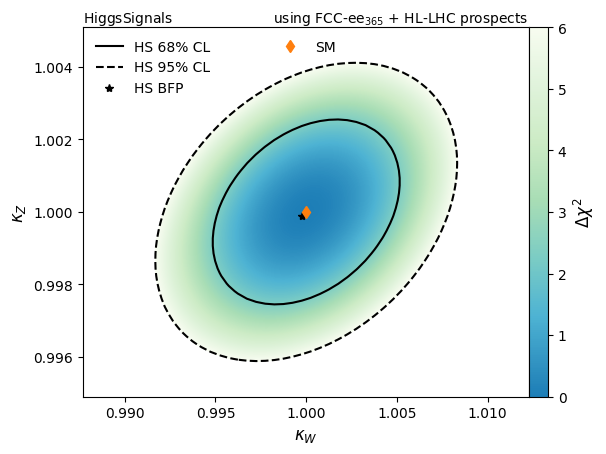

In [46]:
meas = HS.Measurement(measFile)

pred = HP.Predictions()
h = pred.addParticle(HP.NeutralScalar("h", "even"))
h.setMass(125)

coups = HP.scaledSMlikeEffCouplings(1)
HP.effectiveCouplingInput(h, coups, reference="SMHiggsEW")


def getChisq(kappa_WW, kappa_ZZ):
    coups.WW = kappa_WW
    coups.ZZ = kappa_ZZ
    HP.effectiveCouplingInput(h, coups, reference="SMHiggsEW")
    return meas(pred)


test = np.frompyfunc(getChisq, 2, 1)
c_WW = np.linspace(1 - 3*0.41/100., 1 + 3*0.41/100.)
c_ZZ = np.linspace(1 - 3*0.17/100., 1 + 3*0.17/100.)
chisq = test(*np.meshgrid(c_WW, c_ZZ))
chisq = np.array(chisq, dtype="float64")

fig, ax = plt.subplots()
chisqPlot(
    fig,
    ax,
    c_WW,
    c_ZZ,
    chisq,
    experiment=r"FCC-ee$_{365}$ + HL-LHC",
    description="prospects",
    # luminosity=meas.luminosity(),
)
ax.plot(1, 1, c="tab:orange", marker="d", label="SM", ls="none")
ax.legend(loc="upper center", frameon=False)
ax.set_xlabel(r"$\kappa_W$")
ax.set_ylabel(r"$\kappa_Z$")
plt.show()


## Higgs self-coupling at HL-LHC

In [47]:
bins = {
    "effLam": {
        "coupling": "effLam",
        "obsCoupling": [2 - 0.25, 2, 2 + 0.25],
        # "obsCoupling": [2 - 50./100., 2, 2 + 50./100.],
        "process": {"channels": [[p, "WW"] for p in ("H", "vbfH")]},
    },
}


measFile_lam = implementMeasurement(
    "1905.03764",
    "HL-LHC Projection",
    bins,
    # corrMatExp=corrMat,
    prefix="EffLamHL-LHC",
    referenceMass=125.38,
    massResolution=0.15 * 125,  # Change!
    idSuffix=1,
    experiment="LHCComb",
    collider="LHC13",
    luminosity=6000
)

Could not detect experiment
Looks good. Saving this to EffLamHL-LHC_LHC13_LHCComb_6000.json


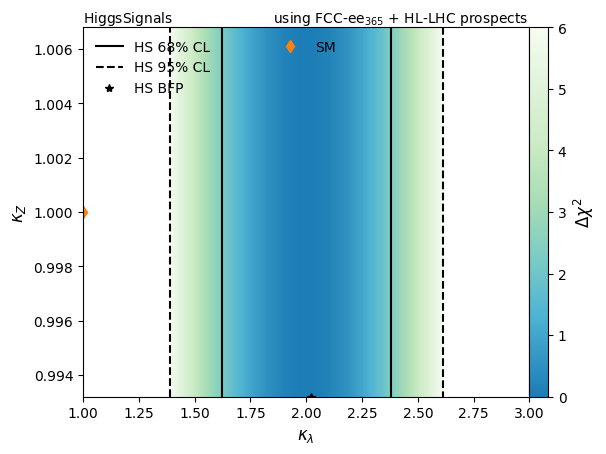

In [48]:
meas_lam = HS.Measurement(measFile_lam)

pred = HP.Predictions()
h = pred.addParticle(HP.NeutralScalar("h", "even"))
h.setMass(125)

coups = HP.scaledSMlikeEffCouplings(1)
HP.effectiveCouplingInput(h, coups, reference="SMHiggsEW")

def getChisq(kappa_Lam, kappa_ZZ):
    coups.lam = kappa_Lam
    coups.ZZ  = kappa_ZZ
    HP.effectiveCouplingInput(h, coups, reference="SMHiggsEW")
    return meas_lam(pred)


test = np.frompyfunc(getChisq, 2, 1)
wgt = 4.
c_Lam = np.linspace(2 - wgt*0.25, 2 + wgt*0.25)
c_ZZ  = np.linspace(1 - wgt*0.17/100., 1 + wgt*0.17/100.)
chisq = test(*np.meshgrid(c_Lam, c_ZZ))
chisq = np.array(chisq, dtype="float64")

fig, ax = plt.subplots()
chisqPlot(
    fig,
    ax,
    c_Lam,
    c_ZZ,
    chisq,
    experiment=r"FCC-ee$_{365}$ + HL-LHC",
    description="prospects",
    # luminosity=meas_lam.luminosity(),
)
ax.plot(1, 1, c="tab:orange", marker="d", label="SM", ls="none")
ax.legend(loc="upper center", frameon=False)
ax.set_xlabel(r"$\kappa_{\lambda}$")
ax.set_ylabel(r"$\kappa_Z$")
plt.show()

## Combined HL-LHC + FCC-ee $_{365}$

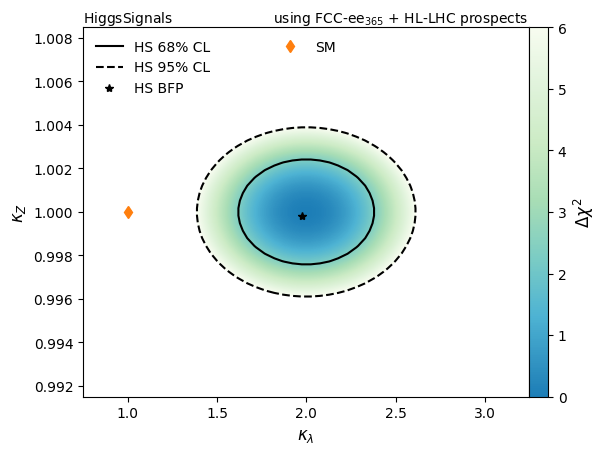

0

In [49]:
pred = HP.Predictions()
h = pred.addParticle(HP.NeutralScalar("h", "even"))
h.setMass(125)

coups = HP.scaledSMlikeEffCouplings(1)
HP.effectiveCouplingInput(h, coups, reference="SMHiggsEW")

# Copy the measurement json files to a common directory
os.system("mkdir future_projections_data")
os.system("cp EffCouplings_FCCee365_FCCeeComb_1500.json future_projections_data/")
os.system("cp EffLamHL-LHC_LHC13_LHCComb_6000.json future_projections_data/")
signals = HS.Signals("future_projections_data")
chisqSM = signals(pred)


def getChisq(kappa_Lam, kappa_ZZ):
    coups.lam = kappa_Lam
    coups.ZZ  = kappa_ZZ
    HP.effectiveCouplingInput(h, coups, reference="SMHiggsEW")
    return signals(pred)


test = np.frompyfunc(getChisq, 2, 1)
wgt = 5.
c_Lam = np.linspace(2 - wgt*0.25, 2 + wgt*0.25)
# c_Lam = np.linspace(2 - wgt*50./100., 2 + wgt*50./100.)
c_ZZ  = np.linspace(1 - wgt*0.17/100., 1 + wgt*0.17/100.)
chisq = test(*np.meshgrid(c_Lam, c_ZZ))
chisq = np.array(chisq, dtype="float64")

fig, ax = plt.subplots()
chisqPlot(
    fig,
    ax,
    c_Lam,
    c_ZZ,
    chisq,
    experiment=r"FCC-ee$_{365}$ + HL-LHC",
    description="prospects",
    # luminosity=meas_lam.luminosity(),
)
ax.plot(1, 1, c="tab:orange", marker="d", label="SM", ls="none")
ax.legend(loc="upper center", frameon=False)
ax.set_xlabel(r"$\kappa_{\lambda}$")
ax.set_ylabel(r"$\kappa_Z$")
plt.show()

os.system("rm -rf future_projections_data")